In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# بارگذاری داده‌ها
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train images:", x_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [3]:
num_classes = len(np.unique(y_train))

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Number of classes:", num_classes)
print("Classes:", class_names)

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


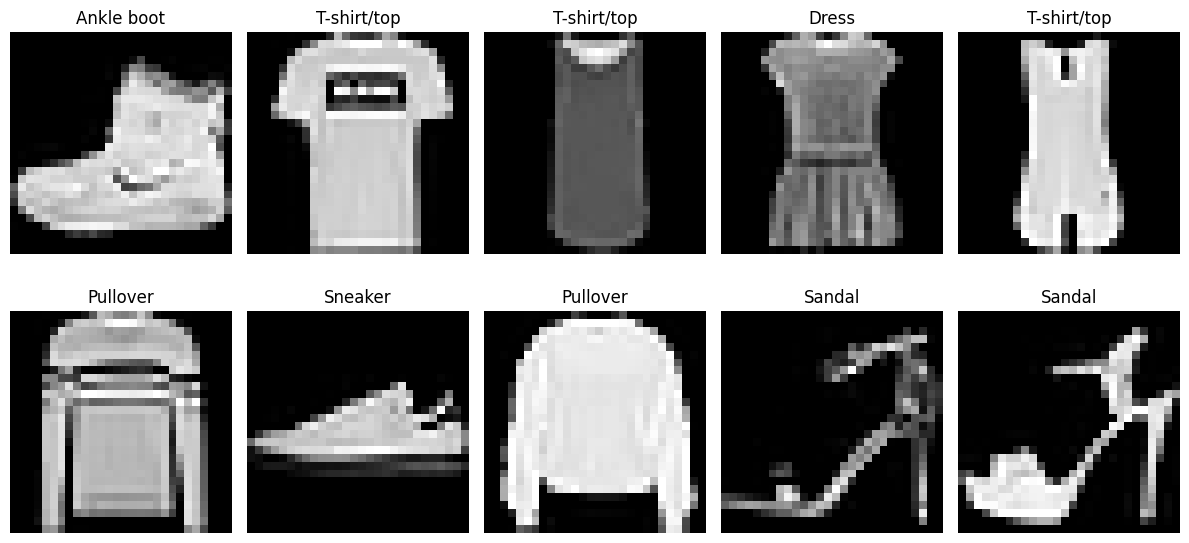

In [4]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum value:", x_train.min())
print("Maximum value:", x_train.max())

Minimum value: 0.0
Maximum value: 1.0


In [6]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [7]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8035 - loss: 0.5575 - val_accuracy: 0.8660 - val_loss: 0.3685
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8756 - loss: 0.3482 - val_accuracy: 0.8858 - val_loss: 0.3085
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8943 - loss: 0.2970 - val_accuracy: 0.8992 - val_loss: 0.2669
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9016 - loss: 0.2711 - val_accuracy: 0.8982 - val_loss: 0.2641
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9099 - loss: 0.2462 - val_accuracy: 0.9065 - val_loss: 0.2487
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9172 - loss: 0.2252 - val_accuracy: 0.9180 - val_loss: 0.2240
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9219 - loss: 0.2109 - val_accuracy: 0.9200 - val_loss: 0.2155
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9286 - loss: 0.1936 - val_accuracy: 

In [10]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9192 - loss: 0.2243
Test Loss: 0.2243088185787201
Test Accuracy: 0.9192000031471252


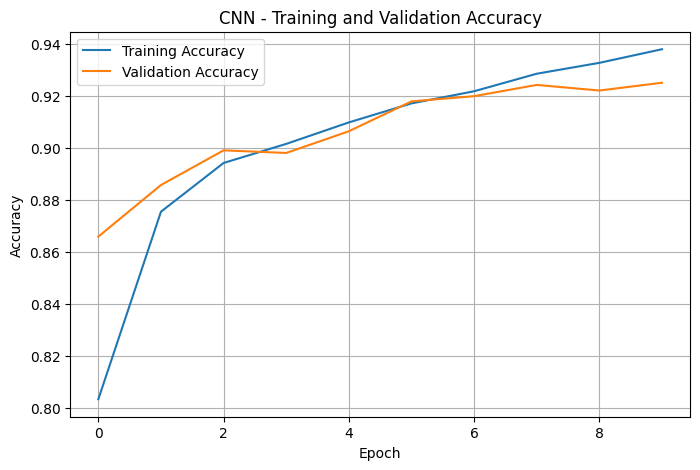

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN - Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

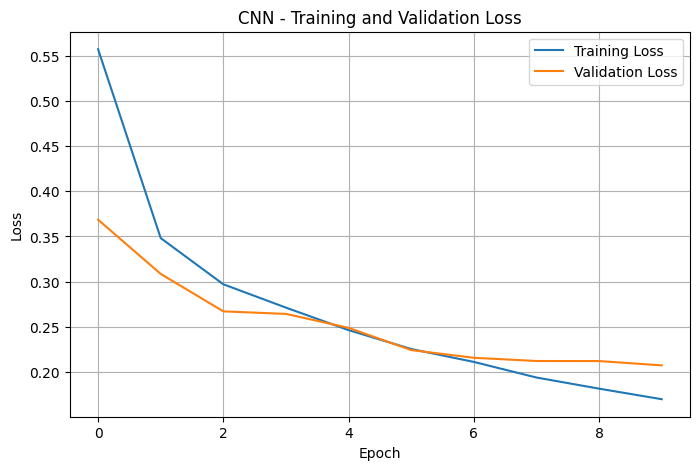

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN - Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [13]:
predictions = model.predict(x_test, verbose=0)

predicted_class = np.argmax(predictions[0])
actual_class = y_test[0]

print("Predicted class:", predicted_class)
print("Actual class:", actual_class)

print("Predicted label:", class_names[predicted_class])
print("Actual label:", class_names[actual_class])

Predicted class: 9
Actual class: 9
Predicted label: Ankle boot
Actual label: Ankle boot


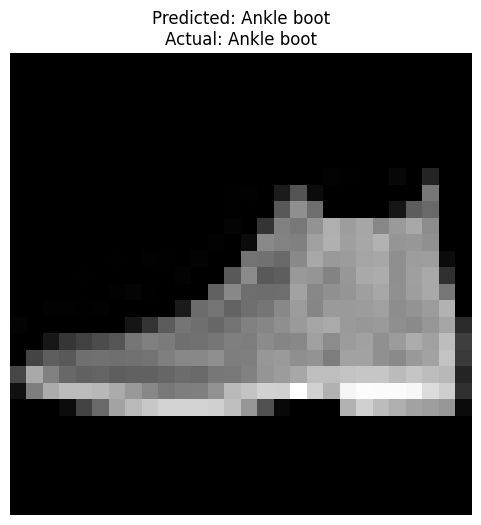

In [14]:
plt.figure(figsize=(6, 6))

plt.imshow(x_test[0].squeeze(), cmap="gray")

plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Actual: {class_names[actual_class]}"
)

plt.axis("off")
plt.show()

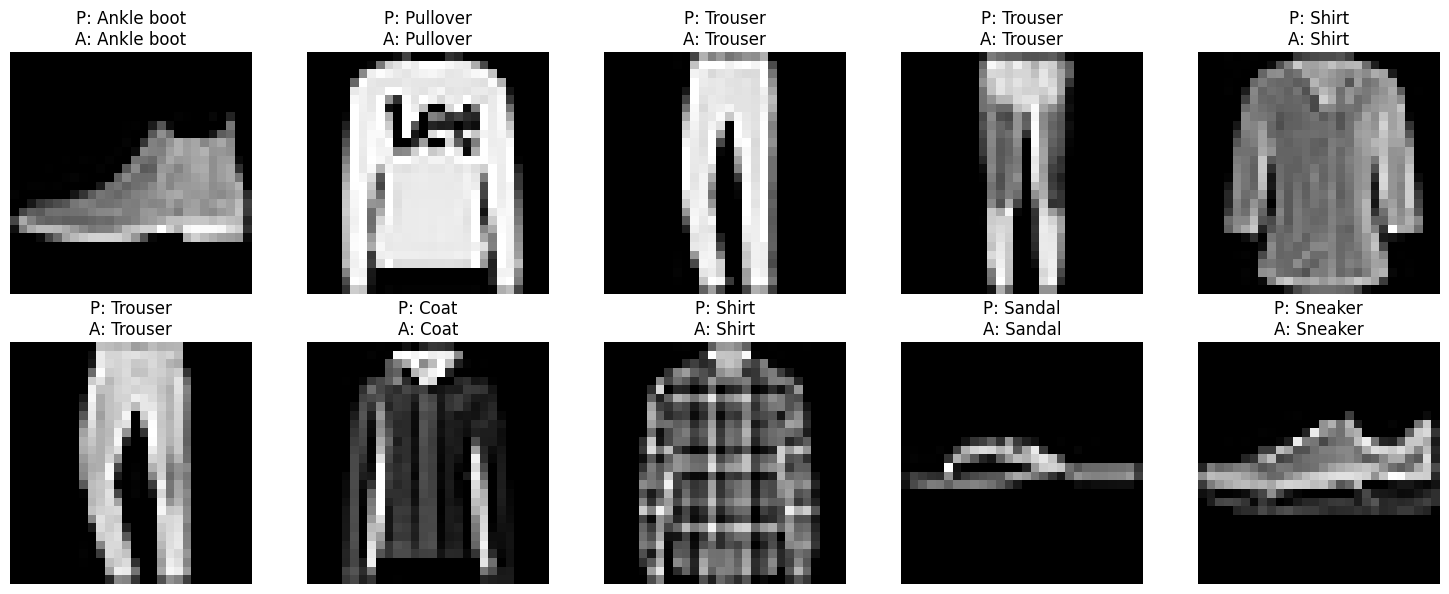

In [15]:
plt.figure(figsize=(15, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i].squeeze(), cmap="gray")

    predicted = np.argmax(predictions[i])
    actual = y_test[i]

    plt.title(
        f"P: {class_names[predicted]}\n"
        f"A: {class_names[actual]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
model.save("fashion_mnist_cnn.keras")

print("CNN model saved successfully.")

CNN model saved successfully.


In [17]:
print("==============================================")
print("Fashion MNIST - CNN")
print("==============================================")

print("Number of classes:", num_classes)
print("Training samples:", len(x_train))
print("Test samples:", len(x_test))
print("Image size: 28 x 28 x 1")
print("Test accuracy:", test_accuracy)

print("==============================================")

Fashion MNIST - CNN
Number of classes: 10
Training samples: 60000
Test samples: 10000
Image size: 28 x 28 x 1
Test accuracy: 0.9192000031471252
